<h1 align=center>CP1 Data Science - EDA</h1>
<p align=center>Eduardo Ulisses</p>
<p align=center>Henrique Guedes</p>
<p align=center>2ESPV</p>


        Preparação e Qualidade dos dados
    
=== HEAD ===
   response_id  company_id  survey_year quarter country  region   industry  \
0            1  COMP-00001         2023      Q1   Italy  Europe  Education   
1            2  COMP-00001         2023      Q2   Italy  Europe  Education   
2            3  COMP-00001         2023      Q3   Italy  Europe  Education   
3            4  COMP-00001         2023      Q4   Italy  Europe  Education   
4            5  COMP-00001         2024      Q1   Italy  Europe  Education   
5            6  COMP-00001         2024      Q2   Italy  Europe  Education   
6            7  COMP-00001         2024      Q3   Italy  Europe  Education   
7            8  COMP-00001         2024      Q4   Italy  Europe  Education   

  company_size  num_employees  annual_revenue_usd_millions  ...  \
0      Startup             57                        48.31  ...   
1      Startup             57                        48.31  ...   
2      Startup             57       

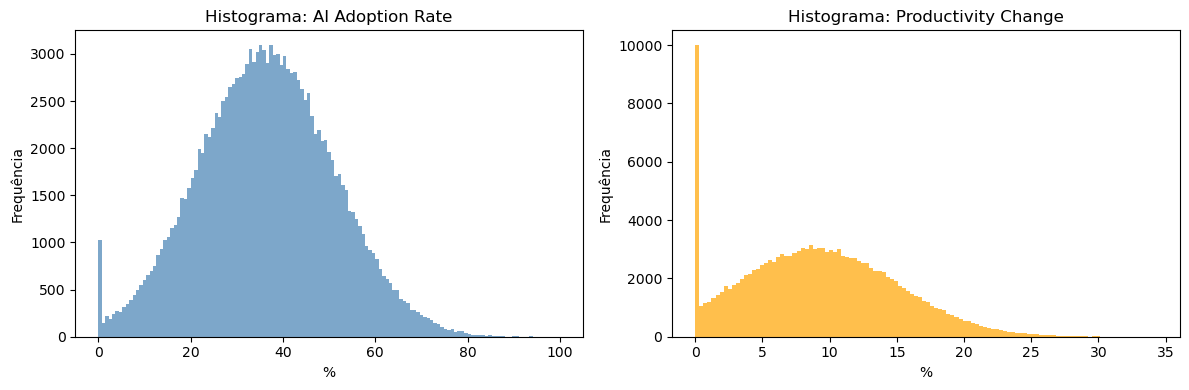


         Correlação entre as variáveis
    
Correlações de Pearson

Correlação entre adoção de ia e aumento na produtividade: 0.675
Correlação entre automação e tempo economizado: 0.793


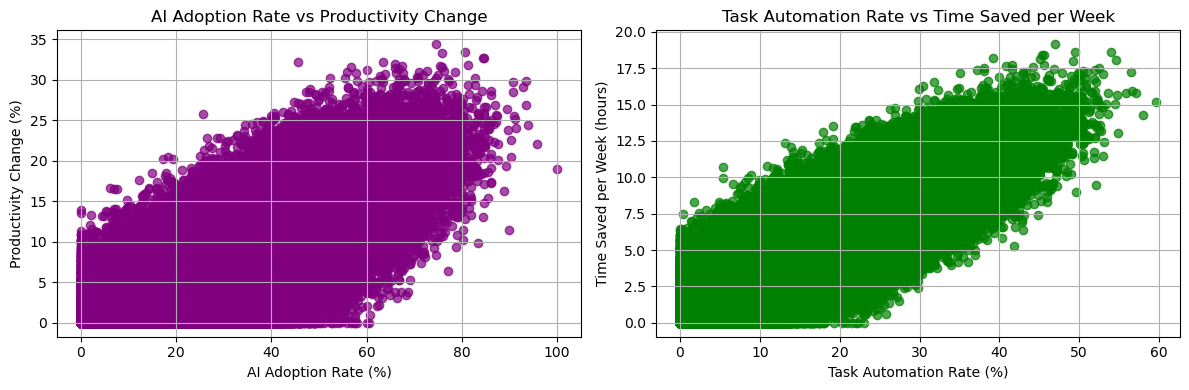


            Outliers com IQR e Boxplot

        
annual_revenue_usd_millions: total de outliers = 27947 | limites=[-581.525, 1059.555]


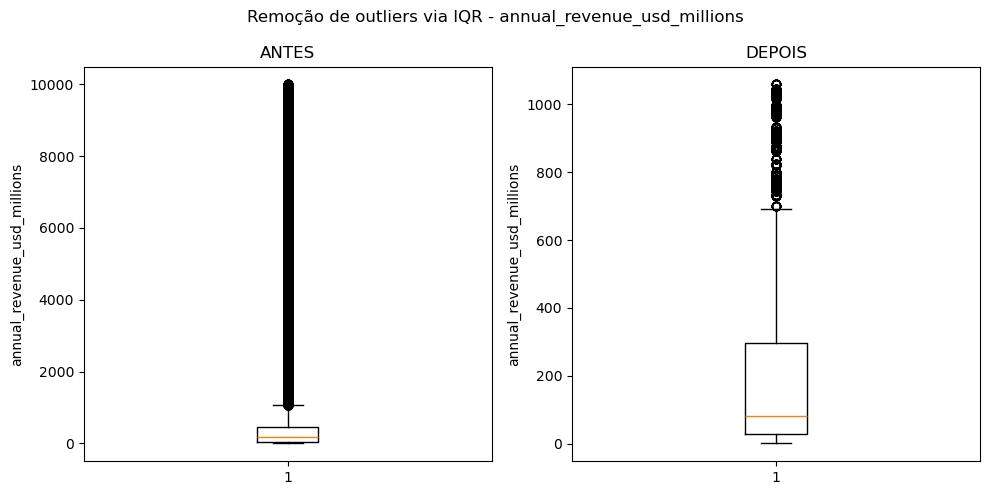

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


data = pd.read_csv("data/raw/ai_company_adoption.csv")
df = data.copy()

print(
    """
        =================================
        Preparação e Qualidade dos dados
        =================================
    """

)

# Visualização inicial
print("=== HEAD ===")
print(df.head(8))

print("\n=== INFO ===")
df.info()

print("\n=== % DE NULOS POR COLUNA ===")
print(df.isnull().mean() * 100)

# Regras de limpeza
print("\n=== DUPLICATAS ===")
print(f"Linhas duplicadas: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

print("\n=== REMOVENDO COLUNAS IRRELEVANTES ===")
colunas_relevantes = [
    'survey_year',
    'country',
    'industry',
    'company_size',
    'num_employees',
    'annual_revenue_usd_millions',
    'ai_adoption_rate',
    'ai_maturity_score',
    'years_using_ai',
    'ai_budget_percentage',
    'productivity_change_percent',
    'task_automation_rate',
    'time_saved_per_week',
    'jobs_displaced',
    'jobs_created',
    'reskilled_employees',
    'revenue_growth_percent',
    'cost_reduction_percent',
    'employee_satisfaction_score',
    'customer_satisfaction'
]
df = df[colunas_relevantes]
print(f"Colunas restantes: {df.shape[1]}\n")
print(df.info())

print("\n=== DATASET FINAL ===")
print(df.shape)

print("\n=== CRIANDO NOVO ARQUIVO CSV ===")
df.to_csv("./data/processed/dataset_clean.csv", index=False)
print("\nNovo arquivo criado em /data/processed/")



data = pd.read_csv("data/processed/dataset_clean.csv")

df = data[['ai_adoption_rate', 'productivity_change_percent']].copy()

print(
    """
    ==========================================
    Estatística descritiva “com interpretação”
    ==========================================
    """
)

print(
    """
    ======================================================================
         Histogramas: Ai Adoption Rate X Productivity Change Percent
    ======================================================================
    """
)
print(df.head(8))
print("\n")
print("\nMédia:\n", df.mean())
print("\nMediana:\n", df.median())
print("\nModa:\n", df.mode())
print("\nVariância Amostral:\n", df.var(ddof=1))
print("\nDP amostral:\n", df.std(ddof=1))




fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ai Adoption Rate Graphics
axes[0].hist(df['ai_adoption_rate'], bins="auto", color="steelblue", alpha=0.7)
axes[0].set_title("Histograma: AI Adoption Rate")
axes[0].set_xlabel("%")
axes[0].set_ylabel("Frequência")

# Productivity Change Percent Graphics
axes[1].hist(df['productivity_change_percent'], bins="auto", color="orange", alpha=0.7)
axes[1].set_title("Histograma: Productivity Change")
axes[1].set_xlabel("%")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()


print(
    """
    ==========================================
         Correlação entre as variáveis
    ==========================================
    """
)

correlacao = df['ai_adoption_rate'].corr(df['productivity_change_percent'])
corr2 = data['task_automation_rate'].corr(data['time_saved_per_week'])

print("Correlações de Pearson\n")
print(f"Correlação entre adoção de ia e aumento na produtividade: {correlacao:.3f}")
print(f"Correlação entre automação e tempo economizado: {corr2:.3f}")

fig, axes2 = plt.subplots(1, 2, figsize=(12,4))

# Scatter 1
axes2[0].scatter(
    df['ai_adoption_rate'],
    df['productivity_change_percent'],
    alpha=0.7,
    color="purple"
)
axes2[0].set_title("AI Adoption Rate vs Productivity Change")
axes2[0].set_xlabel("AI Adoption Rate (%)")
axes2[0].set_ylabel("Productivity Change (%)")
axes2[0].grid(True)

# Scatter 2
axes2[1].scatter(
    data['task_automation_rate'],
    data['time_saved_per_week'],
    color="green",
    alpha=0.7
)
axes2[1].set_title("Task Automation Rate vs Time Saved per Week")
axes2[1].set_xlabel("Task Automation Rate (%)")
axes2[1].set_ylabel("Time Saved per Week (hours)")
axes2[1].grid(True)

plt.tight_layout()
plt.show()

print(
        """
            ==========================
            Outliers com IQR e Boxplot
            ==========================\n
        """
)

df = data.copy()

target = "annual_revenue_usd_millions"

def iqr_outliers(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (series < low) | (series > high)
    return mask, low, high


mask, low, high = iqr_outliers(df[target])
print(f"{target}: total de outliers = {mask.sum()} | limites=[{low:.3f}, {high:.3f}]")

df_raw = df[target].dropna()
df_clean = df.loc[~mask, target].dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(df_raw.values, vert=True)
axes[0].set_title(f"ANTES")
axes[0].set_ylabel(target)

axes[1].boxplot(df_clean.values, vert=True)
axes[1].set_title(f"DEPOIS")
axes[1].set_ylabel(target)

plt.suptitle(f"Remoção de outliers via IQR - {target}")
plt.tight_layout()
plt.show()